# 권한별 서로 다른 벡터 DB 이용  

회사에 마케팅, 재무, 영업 부서가 있다고 가정한다.  

각 부서별로 사원과 임원은 다음의 문서 그룹만을 볼 수 있다.  

**부서별 열람 가능 부서**  

마케팅: 마케팅  

영업: 영업  

재무: 마케팅, 영업, 재무  

임원 : 임원 전용 문서  

임원급의 경우 모든 부서의 문서와 임원급 전용 문서를 볼 수 있다.  


**문서의 등급**  

그리고 각 문서들은 임원급, 부장급, 사원급으로 나뉘어서 관리된다.  

문서의 등급은 각각 A, B, C이며, 각 직급별로 다음의 문서 등급을 볼 수 있다.  



사원급: C  

부장급: B, C  

임원급: A, B, C  



영업, 마케팅, 재무 모두 A, B, C의 세가지 문서 등급이 있다.  


이렇게 직급별, 부서별로 볼 수 있는 문서의 종류와 등급을 고려한 RAG를 구성한다.  

# User와 Document를 pydantic 객체로 선언  

In [2]:
from typing import List, Tuple, Dict, Annotated
from typing_extensions import TypedDict

class User(TypedDict):
    id: int
    name: str
    email: str
    department: str
    rank: str


class RawDocument(TypedDict):
    id: int
    title: str
    content: str
    author_id: int
    created_at: str
    department: str
    rank: str

# 접근 권한 규칙 정의  

In [3]:
department_access = {
    'marketing': ['marketing'],
    'sales': ['sales'],
    'finance': ['marketing', 'sales', 'finance'],
    'executive': ['marketing', 'sales', 'finance', 'executive'],
}

rank_access = {
    'staff': ['C'],
    'manger': ['B', 'C'],
    'executive': ['A', 'B', 'C'],
    'admin': ['A', 'B', 'C'],
}

def filter_documents(user: User, documents: RawDocument) -> List[RawDocument]:
    """
    Filters documents based on user department and rank.
    
    :param user: User object containing user details.
    :param documents: List of Document objects to filter.
    :return: Filtered list of documents.
    """
    accessible_departments = department_access.get(user['department'], [])
    accessible_ranks = rank_access.get(user['rank'], [])
    
    filtered_docs = [
        doc for doc in documents
        if doc['department'] in accessible_departments and doc['rank'] in accessible_ranks
    ]
    
    return filtered_docs

# 가상의 문서 생성  

By Gemini 2.0 Flash  

In [4]:
marketing_docs = {'documents': {'A': ['''[마케팅 - A] 새로운 광고 캠페인 전략 보고서: 
                  이번 분기 새롭게 추진할 광고 캠페인 전략 보고서에서는 
                  핵심 타겟 고객층을 20대 후반에서 30대 초반의 디지털 네이티브로 설정하고, 
                  이들의 온라인 활동 패턴을 분석하여 최적의 광고 채널 및 시간대를 제안합니다. 
                  주요 전략으로는 인스타그램, 유튜브 등 비주얼 중심 플랫폼에서의 브랜드 인지도
                   강화, 숏폼 비디오 콘텐츠를 활용한 흥미 유발, 그리고 관련 분야의 영향력 있는 
                  인플루언서와의 협업을 통한 신뢰도 구축을 포함합니다. 캠페인의 성공적인 진행을 
                  위해 구체적인 예산 배분 계획, 단계별 실행 일정, 그리고 도달수, 전환율, ROI 등 
                  측정 가능한 핵심 성과 지표(KPI)를 명확하게 제시합니다. 또한, 경쟁사 캠페인 분석
                  을 통해 차별화된 전략 포인트를 강조하고, 잠재적인 위험 요소 및 대응 방안을 함께 제시합니다.
                  '''],
                  'B': ['''[마케팅 - B] 이번 달 소셜 미디어 성과 분석: 
                  지난 한 달간 회사의 공식 소셜 미디어 채널(인스타그램, 페이스북, 트위터) 
                  운영 성과를 종합적으로 분석한 보고서입니다. 총 도달수는 지난달 대비 15% 증가한 
                  120만 명을 기록했으며, 게시물에 대한 좋아요, 댓글, 공유 등의 참여율은 8% 상승한
                  5.2%로 나타났습니다. 특히, 특정 신제품 홍보 게시물의 높은 참여율을 심층 분석하여 
                  향후 콘텐츠 제작 방향에 대한 시사점을 도출하고, 각 플랫폼별 팔로워 증감 추이, 인기
                  콘텐츠 유형, 그리고 사용자 반응 분석 결과를 구체적인 데이터와 그래프를 통해 시각
                  적으로 제시합니다. 또한, 소셜 미디어 광고 집행 효율성을 분석하여 예산 배분 최적화
                  방안을 제안하고, 경쟁사 소셜 미디어 활동 분석 결과를 비교하여 개선점을 도출합니다.
                  '''],
                  'C': ['''
                  [마케팅 - C] 마케팅 부서 주간 회의록: 
                  금주 마케팅 부서 정기 회의에서는 다음 주 주요 캠페인 론칭 일정 확정, 신규 콘텐츠 
                  아이디어 브레인스토밍, 그리고 지난주 진행되었던 온라인 이벤트 결과 보고가 주요 
                  안건으로 논의되었습니다. 각 팀별(디지털 마케팅팀, 콘텐츠 제작팀, 브랜드 전략팀) 
                  진행 상황 및 애로사항을 공유하고, 캠페인 협업 방안, 콘텐츠 제작 일정 조율, 
                  그리고 긴급하게 처리해야 할 의사 결정 사항들을 명확하게 기록합니다. 
                  또한, 회의에서 논의된 추가 아이디어 및 결정 사항에 대한 담당자 및 마감일을 
                  명시하여 향후 진행 상황을 추적 관리할 수 있도록 합니다.
                  ''']
                  },
                'metadata': {'department': 'marketing'}
                  }



sales_docs = {'documents': {'A': ['''[영업 - A] 대규모 고객 계약 조건: 
              핵심 고객사인 ABC Corp.과의 대규모 제품 공급 계약에 대한 최종 세부 조건이 명시되어 있습니다.
                총 계약 금액은 50억 원이며, 제품 인도 조건은 계약 후 3개월 이내 분할 배송,
                지불 조건은 제품 인도 완료 후 30일 이내 전액 지급입니다. 특별 할인 조건으로 총 구매 금액의
                3% 할인이 적용되며, 계약 불이행 시의 책임 소재 및 손해 배상 규정 또한 명확하게 기술되어 있습니다.
              법무팀의 최종 검토를 완료한 계약서 원본과 함께, 계약 관련 배경 설명 및 예상되는 기대 효과 분석 자료가 첨부되어 있습니다.
              '''],
              'B': ['''[영업 - B] 지난 분기 판매 실적 보고서:
                지난 3분기(7월-9월)의 전체 판매 실적을 분석한 보고서로, 주력 제품인 XYZ 모델의 판매량은
                5,000대를 기록하여 목표 대비 95% 달성률을 보였습니다. 지역별 판매 현황 분석 결과,
                수도권 지역의 판매량이 전체의 60%를 차지했으며, 지방 시장 확대를 위한 전략 수립의 필요성을 제시합니다.
                또한, 판매 채널별(온라인, 오프라인, B2B) 실적 분석을 통해 각 채널의 강점과 약점을 파악하고,
                판매 부진 제품에 대한 원인 분석 및 개선 방안을 모색합니다. 다음 분기 판매 목표 설정 및 전략 수립을 위한 기초 자료로 활용될 예정입니다.
                '''],
              'C': ['''[영업 - C] 신규 영업 사원 교육 자료:
                새롭게 입사한 영업 사원들을 위한 필수 교육 자료로, 회사의 주요 제품 라인업 소개,
                핵심 영업 프로세스(잠재 고객 발굴, 제안서 작성, 계약 체결, 고객 관리) 안내,
                효과적인 고객 응대 및 커뮤니케이션 방법, 그리고 영업 활동 관련 내부 규정 및 정책 등을 상세하게 설명합니다.
                각 교육 내용에 대한 이해도를 높이기 위해 실제 영업 사례 연구 및 역할극 연습 세션에 대한 안내도 포함되어 있으며,
                교육 수료 후 평가 기준 및 향후 멘토링 프로그램에 대한 정보도 제공합니다.
                ''']
                },
                'metadata': {'department': 'sales'}
                }

finance_docs = {'documents': {'A': ['''[재무 - A] 내년도 예산안:
                2026년도 회사의 전체 예산 계획을 담고 있는 최종 검토 문서입니다. 
                각 사업 부서별(마케팅, 영업, R&D, 생산) 예산 요청 내역, 예상 매출액
                 및 영업 이익, 투자 계획(신규 설비 투자, 연구 개발 투자 등), 
                그리고 거시 경제 전망 및 시장 상황 분석을 기반으로 한 재무 예측을 포함합니다. 
                특히, 신규 사업 진출에 따른 추가 예산 확보 방안 및 비상 자금 운용 계획을 
                상세하게 기술하고 있으며, 예산 집행 통제 및 평가 기준을 명확히 제시하여 
                효율적인 재정 관리를 목표로 합니다. 경영진의 최종 승인을 거쳐 확정될 예정입니다.
                '''],
                'B': ['''[재무 - B] 월별 재무 보고서:
                2025년 4월의 회사 재무 상태를 종합적으로 보여주는 보고서입니다.
                손익계산서에는 매출액, 매출원가, 판매비와관리비, 영업이익 등이 명시되어 있으며,
                전월 대비 증감률 및 주요 변동 요인을 분석합니다. 대차대조표에는 자산, 부채,
                자본 항목별 잔액과 변동 내역을 상세하게 기록하고, 유동비율, 부채비율 등 주요
                재무 비율을 산출하여 회사의 단기 및 장기 재정 건전성을 평가합니다.
                현금흐름표에는 영업활동, 투자활동, 재무활동으로 인한 현금 유입 및 유출 내역을
                보여주어 회사의 현금 관리 능력을 파악할 수 있도록 합니다.
                '''],
                'C': ['''[재무 - C] 경비 처리 규정:
                회사의 모든 임직원이 따라야 하는 경비 처리 절차 및 관련 규정을
                명확하게 명시한 문서의 최신 개정본입니다. 출장비(교통비, 숙박비, 식비) 지급 기준
                및 증빙 서류 안내, 회의비 사용 범위 및 승인 절차, 접대비 한도 및 관련 세금 처리 방법
                등 각 항목별 처리 기준을 구체적으로 설명합니다. 또한, 전자 경비 처리 시스템 사용
                방법 및 주의사항, 부정 경비 처리 시의 징계 규정, 그리고 관련 문의 부서 및 담당자 연락처를
                포함하여 경비 처리 과정에서의 혼란을 최소화하고 투명성을 확보하고자 합니다.
                ''']
                },
                'metadata': {'department': 'finance'}
                }


exceutive_docs = {'documents': {'A': ['''[executive - A] 전사 전략 발표 자료:
                  향후 5년간 (2026년-2030년) 회사의 지속 가능한 성장 및 시장 경쟁력 강화를 위한 전사 전략 발표 자료입니다.
                    거시 경제 동향 분석, 산업별 성장 전망, 경쟁사 분석 결과를 바탕으로 회사의 핵심 역량을 강화하고 새로운 성장 동력을 발굴하기 위한 구체적인 목표와 전략 방향을 제시합니다.
                    각 사업 부문별(주력 사업, 신규 사업) 전략 목표, 시장 확대 방안, 기술 혁신 로드맵,
                    그리고 조직 문화 개선 방안 등을 포함하며, 재무 목표 달성 및 주주 가치 극대화를 위한 전략적 우선순위를 명확히 제시합니다.
                    ''',
                    '''[executive - A] 조직 개편안:
                    급변하는 시장 환경에 대한 신속한 대응력을 높이고, 부서 간 협업 강화 및 의사 결정 효율성을 극대화하기 위한 조직 구조 개편안입니다.
                    기존 기능 중심의 조직 구조를 시장 및 고객 중심 구조로 전환하고, 핵심 사업 부문의 독립성을 강화하며,
                    신규 사업 추진을 위한 전담 조직 신설을 포함합니다.
                    각 부서의 역할과 책임 재정의, 직급 체계 단순화, 그리고 새로운 커뮤니케이션 및 협업 프로세스 도입 방안을 상세하게 설명하며,
                    조직 개편에 따른 예상 효과 및 잠재적인 위험 요소, 그리고 단계별 실행 계획을 제시합니다.
                    ''',
                    '''[executive - A] 임원 회의록:
                    지난주 진행된 임원 회의의 주요 논의 안건, 결정 사항, 그리고 향후 추진 계획 등을 상세하게 기록한 회의록입니다.
                    신규 사업 투자 결정, 주요 고객 계약 진행 상황 보고, 조직 개편안 검토 결과,
                    그리고 다음 분기 경영 목표 설정 등에 대한 각 임원들의 심도 깊은 의견 교환 및 최종 결정 내용을 포함합니다.
                    또한, 각 결정 사항에 대한 책임 부서 및 담당자, 그리고 마감일을 명시하여 향후 진행 상황을 체계적으로 관리할 수 있도록 합니다.
                    ''']
                    },
                    'metadata': {'department': 'executive'}
                    }


In [5]:
#from typing import Dict, List, TypedDict
from typing_extensions import TypedDict

class RawDocument(TypedDict):
    A: List[str]
    B: List[str]
    C: List[str]

class RawMetadata(TypedDict):
    department: str

class RawDocs(TypedDict):
    documents: RawDocument
    metadata: RawMetadata

# 권한과 부서에 따른 별도의 벡터 DB 생성   

마케팅 - A, B, C  
재무 - A, B, C  
영업 - A, B, C  
임원 - A  

10개의 DB  

In [79]:
import google.generativeai as genai
import pathlib
import os
import time
import textwrap
from IPython.display import display
from IPython.display import Markdown
from dotenv import load_dotenv

# .env 파일 로드
load_dotenv()


def to_markdown(text):
  text = text.replace('•', '  *')
  return Markdown(textwrap.indent(text, '> ', predicate=lambda _: True))

# Used to securely store your API key
#from google.colab import userdata
# Or use `os.getenv('GOOGLE_API_KEY')` to fetch an environment variable.
#GOOGLE_API_KEY=userdata.get(API_KEY)

# Gemini API Key  
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

# Gemini API 키 설정
genai.configure(api_key=GEMINI_API_KEY)

# Credentials 관련 조치
credentials_path = os.getenv("GEMINI_CREDENTIALS")
#print(credentials_path)
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = credentials_path
time.sleep(1)  # Let the environment variable propagate

# 빈 Vectodatabases 생성  

In [ ]:
# 빈 Vectordatabases 생성  

import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_community.vectorstores import FAISS
from langchain_google_genai import GoogleGenerativeAIEmbeddings

# Initialize the vector store
embeddings_model = GoogleGenerativeAIEmbeddings(model="models/embedding-001")

index = faiss.IndexFlatL2(len(embeddings_model.embed_query("hello world")))

'''
vectorstore = FAISS(
    embedding_function=embeddings_model,
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={},
)

# 벡터 DB 저장
vectorstore.save_local("faiss_index")
'''

available_departments = ['marketing', 'sales', 'finance', 'executive']


for department in available_departments:
    for rank in ['A', 'B', 'C']:
        if department == 'executive' and rank != 'A':
            continue
        else:
            vectorstore = FAISS(
                            embedding_function=embeddings_model,
                            index=index,
                            docstore=InMemoryDocstore(),
                            index_to_docstore_id={},
                        )
            faiss_name = f'faiss_index_{department}_{rank}'
            vectorstore.save_local(faiss_name)


# Load FAISS vector db  

'''
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import FAISS

model_name = "google/gemma-2-2b-it"

# 임베딩 모델 선택 (Sentence Transformers 외 여러 모델 가능  )
# 기본적으로 GPU를 사용한다  
#embeddings = HuggingFaceEmbeddings(model_name=model_name)

# CPU 모델로 가져오기

embeddings = HuggingFaceEmbeddings(model_name=model_name,
                                   model_kwargs = {'device': 'cpu'})


# 저장했던 경로에서 FAISS 벡터 DB를 불러옵니다.
db = FAISS.load_local("faiss_index", embeddings)
'''


# Raw 텍스트를 벡터 DB에 저장    

In [7]:
from uuid import uuid4

from langchain_core.documents import Document


def select_vector_db(department: str, rank: str) -> str:
    """
    Selects the vector database based on the documents.
    
    :param documents: List of RawDocument objects.
    :return: selected vector database path
    """
    available_departments = ['marketing', 'sales', 'finance', 'executive']
    if department in available_departments:
        return f"faiss_index_{department}_{rank}"
    else:
        raise ValueError("Invalid department")

def load_n_save_vectordatabase(langchain_docs: List, doc_ids: List, vector_db_path: str) -> None:
    # Load the vector store
    vectorstore = FAISS.load_local(vector_db_path, 
                                   embeddings_model, 
                                   allow_dangerous_deserialization=True)
    # Add documents to the vector store
    vectorstore.add_documents(langchain_docs)
    # Save the vector store
    vectorstore.save_local(vector_db_path)


def add_to_vectordatabase(documents: RawDocs) -> None:
    """
    Converts a list of RawDocument to langchain Document format
    and adds them to the vector database.
    
    :param documents: List of RawDocument objects.
    :return: List of langchain Document objects.
    """

    department = documents['metadata']['department']
    
    for doc_rank, ranked_docs in documents['documents'].items():
        langchain_docs = []
        uuids = []
        for doc in ranked_docs:
            doc_id = str(uuid4())
            langchain_doc = Document(
                page_content=doc,
                metadata={
                    "id": doc_id,
                    "department": department,
                    "rank": doc_rank
                }
            )
            langchain_docs.append(langchain_doc)
            uuids.append(doc_id)
        print(f'Department: {department}, Rank: {doc_rank}')
        print(f'Document samples: {langchain_docs[0:5]}')
        # Vector DB에 추가하고 저장까지 완료 
        vectordatabase_path = select_vector_db(department, doc_rank)
        load_n_save_vectordatabase(langchain_docs, uuids, vectordatabase_path)

# RAG with LangGraph    

In [8]:
import os

# 환경 변수 불러오기
LANGSMITH_TRACING_V2 = os.getenv("LANGSMITHTRACING_V2")
LANGSMITH_API_KEY = os.getenv("LANGSMITH_API_KEY")
LANGSMITH_PROJECT = os.getenv("LANGSMITH_PROJECT")


# GraphState 정의  

In [57]:
from typing import Annotated, List
from typing_extensions import TypedDict

from langchain_core.documents import Document
from langgraph.graph.message import add_messages
import operator

# State 정의
class GraphState(TypedDict):
    context: Annotated[List[str], operator.add]
    filtered_context: Annotated[List[str], operator.add]
    answer: Annotated[str, "answer"]
    question: Annotated[str, "question"]
    slq_query: Annotated[str, "SQL Query"]
    relevance_scores: Annotated[List[int], operator.add]
    rag_decision: Annotated[List[str], '[Retrieval] or [No Retrieval]']
    is_rag: Annotated[bool, 'True means do RAG']
    is_contexts_empty: Annotated[bool, 'True means empty contexts']
    is_hallucinated: Annotated[bool, 'Hallucination check']
    groundedness_score: Annotated[int, 'groundedness check']
    is_grounded: Annotated[bool, 'groundedness check']
    response_relevancy_score: Annotated[float, 'answer relevancy score']
    faithfulness_score: Annotated[float, 'answer faithfulness score']
    messages: Annotated[list, add_messages]
    user: User



# Node 정의  

## RAG Decision Making  

유저의 질문에 따라서 RAG를 수행할지 말지를 결정한다.  

In [30]:
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage, HumanMessage
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI

model_name = 'gemini-1.5-flash'

config = {
    "model": "gemini-1.5-flash",  # or other model IDs
    "temperature": 0.4,
    "max_tokens": None,
    "top_p": 0.8,
    # For Vertex AI only:
    #"project": "your-project-id",  # Required for Vertex AI
    #"location": "us-central1",     # Required for Vertex AI
}

rag_decision_instruction = """Determine if the following information
 is related to departments of sales, finance, marketing, or executives. \n
Respond with either [Retrieval] or [No Retrieval].
"""

rag_decision_prompt = ChatPromptTemplate.from_messages(
    [
        ('system', rag_decision_instruction),
        ('human', 'User question: {question}')
    ]
)



rag_decision_making_llm = ChatGoogleGenerativeAI(
    model=config["model"],
    temperature=config["temperature"],
    max_tokens=config["max_tokens"],
    top_p=config["top_p"],
)


rag_decision_maker = rag_decision_prompt | rag_decision_making_llm


def rag_decide(state: GraphState) -> bool:
    print('----- RAG Decision -----')
    # RAG 여부 결정 
    rag_decision_result = rag_decision_maker.invoke({'question': state['question']})
    print(rag_decision_result)
    print(type(rag_decision_result))
    #state['rag_decision'] = rag_decision_result.content
    rag_decision_result = [rag_decision_result.content]
    return GraphState(rag_decision=rag_decision_result)



## RAG decision router  

In [11]:
# RAG 여부를 체크하는 함수(router)  
    
def is_rag(state: GraphState) -> bool:
    print(state['rag_decision'])
    if isinstance(state['rag_decision'], list):
        if state['rag_decision'][-1] == '[Retrieval]':
            return True
        else:
            return False
    else:
        return False

## Retrieve by Department and Rank  

부서와 직급을 고려하여 retrieve  


In [32]:
import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_community.vectorstores import FAISS
from langchain_google_genai import GoogleGenerativeAIEmbeddings

# Initialize the vector store
embeddings_model = GoogleGenerativeAIEmbeddings(model="models/embedding-001")

def retrieve(state: GraphState) -> GraphState:
    print('----- Retrieving Process -----')
    # Select Vector DBs
    user_info = state['user']
    accessible_departments = department_access[user_info['department']]
    accessible_ranks = rank_access[user_info['rank']]

    query = state['question']
    print(f'query of Retrieve: {query}')
    contexts = []
    for department in accessible_departments:
        for rank in accessible_ranks:
            if department == 'executive' and rank != 'A':
                continue
            vectorstore = select_vector_db(department, rank)
            print(f'vesctorestore path: {vectorstore}')
            vectorstore = FAISS.load_local(vectorstore, 
                                    embeddings_model, 
                                    allow_dangerous_deserialization=True)
            results = vectorstore.similarity_search_with_score(query, k=1)
            print(f'Dept. {department}  \n retrieved contexts: {results}')
            for result in results:
                doc_info, score = result
                contexts.append(doc_info.page_content.strip())
        # Retrieve the contexts
    #state['context'] = contexts
    return GraphState(context=contexts)

## Contexts Relevance Check  

Retrieved contexts의 유저의 question과의 relevance를 검사한다.  
0이면 관련이 없고, 1이면 부분적으로 일치, 2면 완전 일치.  
1 이상인 문서만 남기도록 필터링한다.  

기존과 다르게 OpenAI의 API를 사용한다.  

여러 LLM의 API를 동시에 사용하는 실습 용도다.  

In [68]:
# RAGAS에서 trace_roots 에서 index 문제가 발생해서 직접 평가하는 방식으로 변경
# RAGAS의 ContextRelevance를 약간 변형하여 사용 
# https://github.com/explodinggradients/ragas/blob/main/src/ragas/metrics/_nv_metrics.py


# OpenAI 사용  
import openai
from langchain_openai import OpenAI, ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate


# OpenAI API Key 설정
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
openai.api_key = OPENAI_API_KEY

# OpenAI LLM Wrappers (ChatGPT 또는 GPT-4 모델 사용)
rag_evaluator_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.4)

# OpenAI Embeddings Wrapper
rag_evaluator_embeddings = OpenAIEmbeddings(api_key=OPENAI_API_KEY)


# Context Relevance Prompt

context_relevance_template = """
 ### Instructions\n\n
You are a world class expert designed to evaluate the relevance score of a Context
    in order to answer the Question.\n"
Your task is to determine if the Context contains proper information to answer the Question.\n
Do not rely on your previous knowledge about the Question.\n
Use only what is written in the Context and in the Question.\n
Follow the instructions below:\n"
0. If the context does not contains any relevant information to answer the question, say 0.\n
1. If the context partially contains relevant information to answer the question, say 1.\n
2. If the context contains any relevant information to answer the question, say 2.\n
You must provide the relevance score of 0, 1, or 2, nothing else.\nDo not explain.\n
### Question: {question}\n\n"
### Context: {context}\n\n"
Do not try to explain.\n"
Analyzing Context and Question, the Relevance score is 
"""


context_relevance_prompt = PromptTemplate.from_template(context_relevance_template)


rag_evaluator_chain = context_relevance_prompt | rag_evaluator_llm


def filter_context(relevance_score: int) -> bool:
    if relevance_score > 0:
        return True
    else:
        return False




def relevance_check(state: GraphState) -> GraphState:
    # 부서별로 컨텍스트를 받아오기 때문에 부서별로 relevance_scores를 계산한다. \
    print('------ Context Relevance Check ------')
    relevance_scores = []
    relevant_contexts = []
    for context in state['context']:
        eval_data = {'question': state['question'],
                     'context': context}
        
        relevance_score = rag_evaluator_chain.invoke(eval_data)
        
        print(f'context_relevance: {relevance_score}')
        
        relevance_score = int(relevance_score.content)
        
        print(f'relevance_score: {relevance_score}')
        
        if filter_context(relevance_score):
            relevance_scores.append(relevance_score)
            relevant_contexts.append(context)
        else:
            continue
        
    print(f'relevance_scores: {relevance_scores}')
    #state['relevance_scores'] = relevance_scores
    print(f'{len(relevant_contexts)} retrieved contexts:')
    if len(relevant_contexts) > 0:
        print(f'sample - {relevant_contexts[0][0:20]}')
    return GraphState(relevance_scores=relevance_scores,
                      filtered_context=relevant_contexts)


## Context Relevance Router  

필터링 이후 contexts가 없다면 = 비었다면 vanilla generate로 연결한다.  

만약 relevant contexts가 있다면 retrieval-augmented generate로 연결한다.  

In [56]:
# 필터링 이후 contexts가 없다면 vanilla generate로 연결
def is_context_empty(state: GraphState) -> GraphState:
    print('----- Is Context Empty -----')
    print(f'filtered context length: {len(state["filtered_context"])}')
    if state['filtered_context']:
        return 'Not Empty'
    else:
        return 'Empty'

## RAG LLM  

retrieval-augmented generate

In [58]:
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate


model_name = 'gemini-1.5-flash'

rag_system_template = """You are an expert knowledge retriever and answer generator. Your goal is to provide accurate and truthful answers based on the provided context and the user's query.

### Instructions: ###

1.  **Analyze the User Input:** Carefully understand the user's question and identify the core intent.
2.  **Leverage the Context:** Use the provided context as the primary source of information to answer the user's query.
3.  **Synthesize Information:** Combine relevant information from the context to formulate a comprehensive and accurate answer.
4.  **Prioritize Groundedness:** Ensure that every piece of information in your answer can be directly attributed to the provided context. Do not invent or assume information that is not explicitly stated in the context.
5.  **Avoid Hallucinations:** Do not generate any information that is not supported by the context. If the context does not contain the answer to the user's query, state clearly that the answer cannot be found in the provided information. Do not try to answer speculatively or make assumptions.
6.  **Cite Sources (Optional but Recommended):** If possible and relevant, briefly indicate which part of the context supports each piece of information in your answer. This further enhances groundedness.
7.  **Maintain Conciseness and Clarity:** Provide a clear, concise, and direct answer to the user's query based on the context.

"""

rag_prompt = ChatPromptTemplate.from_messages(
    [
        ('system', rag_system_template),
        ('human', '### Context ###:\n {contexts} \n\n### User question ###: {question} ')
    ]
)


rag_llm = ChatGoogleGenerativeAI(
    model=config["model"],
    temperature=config["temperature"],
    max_tokens=config["max_tokens"],
    top_p=config["top_p"],
)


rag = rag_prompt | rag_llm

def retrieved_generate(state: GraphState) -> GraphState:
    print('----- Retreival Agumented Generate -----')
    # RAG
    context_string = '\n'.join(state['filtered_context']).strip()
    response = rag.invoke({'contexts': context_string, 
                            'question': state['question']})
    #state['answer'] = response.content
    return GraphState(answer=response.content)



## Groundedness Check  

정답의 Groundedness를 측정한다.  
즉 Hallucination이 있는지 없는지 평가한다.  

0은 response가 context에 기초하고 있지 않다.  
1은 response가 context에 부분적으로 기반하고 있다.  
2은 response가 context에 완전히 기반하고 있다.  

In [59]:

model_name = 'gemini-1.5-flash'

config = {
    "model": "gemini-1.5-flash",  # or other model IDs
    "temperature": 0.4,
    "max_tokens": None,
    "top_p": 0.8,
    # For Vertex AI only:
    #"project": "your-project-id",  # Required for Vertex AI
    #"location": "us-central1",     # Required for Vertex AI
}


# Initialize with Google AI Studio
hallucination_evaluator_llm = ChatGoogleGenerativeAI(
    model=config["model"],
    temperature=config["temperature"],
    max_tokens=config["max_tokens"],
    top_p=config["top_p"],
)

# Response Groundedness Prompt

response_groundedness_template = """
 ### Instructions\n\n
You are a world class expert designed to evaluate the groundedness of an assertion.\n"
You will be provided with an assertion and a context.\n
Your task is to determine if the assertion is supported by the context.\n
Follow the instructions below:\n
A. If there is no context or no assertion or context is empty or assertion is empty, say 0.\n
B. If the assertion is not supported by the context, say 0.\n
C. If the assertion is partially supported by the context, say 1.\n
D. If the assertion is fully supported by the context, say 2.\n
You must provide a rating of 0, 1, or 2, nothing else.\n\n
### Context:\n
<{context}>\n\n
### Assertion:\n
<{response}>\n\n
Analyzing Context and Response, the Groundedness score is 
"""


response_groundedness_prompt = PromptTemplate.from_template(response_groundedness_template)


groundedness_evaluator_chain = response_groundedness_prompt | hallucination_evaluator_llm


def hallucination_check(state: GraphState) -> GraphState:
    # 부서별로 컨텍스트를 받아오기 때문에 부서별로 relevance_scores를 계산한다. \
    print('------ Groundedness (Hallucination) Check ------')
    user_input = state['question']
    contexts = state['filtered_context']
    answer = state['answer']

    eval_data = {
                'response': answer,
                'context': contexts
            }

    # Relevance Check: 관련성 확인
    groundedness_score = groundedness_evaluator_chain.invoke(eval_data)

    print(f'groundedness_score: {groundedness_score}')

    groundedness_score = int(groundedness_score.content)
    
    print(f'groundedness_score: {groundedness_score}')
    #state['groundedness_score'] = groundedness_score
    return GraphState(groundedness_score=groundedness_score)


## Groundedness Router  


In [17]:
def is_grounded(state: GraphState) -> GraphState:
    if state["groundedness_score"] > 0:
        return True
    else:
        return False   

## Response Relevancy and Faithfulness   

Response Relevancy로 Response가 유저의 question과 얼마아 연관있는지를 평가한다.  

Faithfulness는 Groundeness와 유사하지만 약간 다르다. Response에 있는 개별 주장들 claims or statements가 얼마나 Contexts에 근거하는지를 평가한다. 여러개의 주장들이 consistent, 일관적으로 contexts에 기초하는지를 평가한다.  


## Response Relevancy  

In [18]:
import numpy as np

# OpenAI Embeddings Wrapper
response_relevance_evaluator_embeddings = OpenAIEmbeddings(api_key=OPENAI_API_KEY)


def calculate_similarity(sequence_0: str, sequence_1: str) -> float:
    seq_vec_0 = np.asarray(response_relevance_evaluator_embeddings.embed_query(sequence_0)).reshape(1, -1)
    seq_vec_1 = np.asarray(response_relevance_evaluator_embeddings.embed_query(sequence_1)).reshape(1, -1)
    norm = np.linalg.norm(seq_vec_0, axis=1) * np.linalg.norm(
            seq_vec_1, axis=1
        )
    return (
            np.dot(seq_vec_0, seq_vec_1.T).reshape(
                -1,
            )
            / norm
        )

def response_relevancy_check(state: GraphState) -> GraphState:
    print('------ Response Relevancy ------')
    response_relevancy_score = calculate_similarity(state['question'], 
                                                    state['answer'])
    print(f'response_relevancy_score: {response_relevancy_score}')
    response_relevancy_score = float(response_relevancy_score[0])
    print(f'response_relevancy_score: {response_relevancy_score}')
    
    return GraphState(response_relevancy_score=response_relevancy_score)
    


## Faithfulness  

In [19]:
# Faithfullness

from langchain_core.prompts import ChatPromptTemplate, PromptTemplate

instruction = """Given a question and an answer, analyze the complexity of each sentence in the answer. \n
Break down each sentence into one or more fully understandable statements. \n
Ensure that no pronouns are used in any statement. Format the outputs in JSON.

### contexts ###:\n
John is a student at XYZ University. 
He is pursuing a degree in Computer Science. 
He is enrolled in several courses this semester, 
including Data Structures, Algorithms, and Database Management. 
John is a diligent student and spends a significant amount of time 
studying and completing assignments. 
He often stays late in the library to work on his projects.


statements=[
"John is majoring in Biology.",
"John is taking a course on Artificial Intelligence.",
"John is a dedicated student.",
"John has a part-time job.",


statement="John is majoring in Biology.",
reason="John's major is explicitly mentioned as Computer Science. There is no information suggesting he is majoring in Biology.",
verdict=0,


statement="John is taking a course on Artificial Intelligence.",
reason="The context mentions the courses John is currently enrolled in, and Artificial Intelligence is not mentioned. Therefore, it cannot be deduced that John is taking a course on AI.",
verdict=0,


statement="John is a dedicated student.",
reason="The context states that he spends a significant amount of time studying and completing assignments. Additionally, it mentions that he often stays late in the library to work on his projects, which implies dedication.",
verdict=1,

statement="John has a part-time job.",
reason="There is no information given in the context about John having a part-time job.",
verdict=0

"""


In [20]:
model_name = 'gemini-1.5-flash'

config = {
    "model": "gemini-1.5-flash",  # or other model IDs
    "temperature": 0.4,
    "max_tokens": None,
    "top_p": 0.8,
    # For Vertex AI only:
    #"project": "your-project-id",  # Required for Vertex AI
    #"location": "us-central1",     # Required for Vertex AI
}



statements_creator_llm = ChatGoogleGenerativeAI(
    model=config["model"],
    temperature=config["temperature"],
    max_tokens=config["max_tokens"],
    top_p=config["top_p"],
)


create_statements_template = """
Given an answer, analyze the complexity of each sentence in the answer. 
Break down each sentence into one or more fully understandable statements.
Ensure that no pronouns are used in any statement. 
Each statement is written in Korean.
Format the outputs in JSON format. 

\n\n
### Answer: {answer}\n\n
"""

create_statements_prompt = PromptTemplate.from_template(create_statements_template)

# JSON 형태 output으로 수정 필요  

from pydantic import BaseModel, Field

class Statements(BaseModel):
    sentence: str = Field(description='original sentence')
    statements: List[str] = Field(..., description="statements from original sentence")
    complexity: str = Field(description='complexity of original sentence')

from langchain_core.output_parsers import JsonOutputParser


# 파서를 설정하고 프롬프트 템플릿에 지시사항을 주입합니다.
# 그러면 Topic 클래스의 템플릿에 맞는 형태로 JSON으로 반환.  
parser = JsonOutputParser(pydantic_object=Statements)

create_statements_prompt = create_statements_prompt.partial(format_instructions=parser.get_format_instructions())

statements_creator_chain = create_statements_prompt | statements_creator_llm | parser


def sentenceStatements(TypedDict):
    sentence: Annotated[str, 'orginal sentence']
    statements: Annotated[List[str], 'extracted statements from original sentence']


def GeneratedStatements(TypedDict):
    sentences: List[sentenceStatements]


def create_statements(state: GraphState) -> GeneratedStatements:
    statements = statements_creator_chain.invoke({'answer': state['answer']})
    return statements


In [60]:
faithfulness_evaluator_llm = ChatGoogleGenerativeAI(
    model=config["model"],
    temperature=config["temperature"],
    max_tokens=config["max_tokens"],
    top_p=config["top_p"],
)


faithfulness_score_template = """
Given a contexts and an answer, analyze if the statement can be inferred from given contexts.
\n \n
Follow the instructions below:\n"
0. If the statement can not be inferred from any relevant information in the given contexts, say 0.\n
1. If the statement can be inferred from relevant information in the given contexts, say 1.\n
You must provide the relevance score of 0, or 1, nothing else.\nDo not explain.\n\n
### Answer: {answer}\n\n
### Contexts: {context}\n\n
Do not try to explain.\n
Analyzing Contexts and statements, the faithfullness score is 
"""

faithfulness_score_prompt = PromptTemplate.from_template(faithfulness_score_template)

faithfulness_evaluator_chain = faithfulness_score_prompt | faithfulness_evaluator_llm 

faithfulness_scores = []


def faithfulness_check(state: GraphState) -> GraphState:
    print('----- Faithfulness Check -----')
    # Create Statements
    statements_data = create_statements(state)
    statements_data = statements_data['sentences']

    context = state['filtered_context']
    n_faithful_statements = 0
    n_statements = 0
    for statement_element in statements_data:
        statements = statement_element['statements']
        for statement in statements:
            print(f'statement: {statement}')
            eval_data = {'answer': statement,
                        'context': context}
            faithfulness_score = faithfulness_evaluator_chain.invoke(eval_data)
            print(faithfulness_score)
            #break
            faithfulness_score = int(faithfulness_score.content)
            n_faithful_statements += faithfulness_score
            n_statements += 1

    faithfulness_score = n_faithful_statements / n_statements
    return GraphState(faithfulness_score=faithfulness_score)


## 쿼리 재작성  

Hallucination이 있다면 질문을 더 낫게 변형해서 다시 RAG를 수행한다.  

In [40]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser


rewriter_llm = ChatGoogleGenerativeAI(
    model=config["model"],
    temperature=config["temperature"],
    max_tokens=config["max_tokens"],
    top_p=config["top_p"],
)


# 시스템 프롬프트 정의
# 입력 질문을 벡터스토어 검색에 최적화된 형태로 변환하는 시스템 역할 정의
system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for vectorstore retrieval. Look at the input and try to reason about the underlying semantic intent / meaning."""

# 시스템 메시지와 초기 질문을 포함한 프롬프트 템플릿 생성
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

# 질문 재작성기 생성
question_rewriter = re_write_prompt | rewriter_llm 


def rewrite_query(state: GraphState) -> GraphState:
    print('----- Rewrite Question -----')
    # Query Transform: 쿼리 재작성
    new_question = question_rewriter(state['question'])
    #state['question'] = new_question
    return GraphState(question=new_question)


## RAG 없이 생성  

In [37]:
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate


model_name = 'gemini-1.5-flash'

vanilla_system_template = """You are a corporate expert.
Response professionally.\n\n
"""

vanilla_prompt = ChatPromptTemplate.from_messages(
    [
        ('system', vanilla_system_template),
        ('human', 'User question: {question}')
    ]
)


vanilla_llm = ChatGoogleGenerativeAI(
    model=config["model"],
    temperature=config["temperature"],
    max_tokens=config["max_tokens"],
    top_p=config["top_p"],
)


vanilla_chain = vanilla_prompt | vanilla_llm


def vanilla_generate(state: GraphState) -> bool:
    print('----- Vanilla Generate -----')
    # RAG 여부 결정 
    result = vanilla_chain.invoke({'question': state['question']})
    #state['answer'] = result.content
    return GraphState(answer=result.content)



# 최종 답변  

최종 답변을 messages의 형태로 반환한다.  
이를 통해서 user에게 최종적인 결과를 준다.  

In [24]:
def final_answer(state: GraphState) -> GraphState:
    print('------ LLM Messages ------')
    return GraphState(messages=[('user', state['question']) ,
                                'assistant', state['answer']])


# 그래프 정의  

## 그래프 시각화 함수  

In [25]:
from IPython.display import Image, display

def visualize_graph(graph):
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception:
        # This requires some extra dependencies and is optional
        pass

## User Info 설정  

부서와 직급을 위해서 사용자의 정보를 가져온다.  
본래는 웹서비스의 로그인을 통한 유저 정보나 기타 방법으로 가져와야겠지만,  
여기서는 일단 임의로 user 데이터를 설정한 다음 global 변수로 가져와서 사용한다.   

In [26]:
def set_user_info(state: GraphState) -> GraphState:
    user_data = {"id": 123, 
                 "name": "김철수", 
                 "email": "chulsoo.kim@example.com", 
                 "department": "executive", 
                 "rank": "executive"}
    return GraphState(user=User(**user_data)) # 딕셔너리를 User 타입으로 변환하여 저장


def get_user_data():
    global user_data
    return user_data

def set_user_info(state: GraphState) -> GraphState:
    user_data = get_user_data()
    return GraphState(user=User(**user_data)) # 딕셔너리를 User 타입으로 변환하여 저장



## 전처리 함수  

messages에서 question을 가져온다.  

In [27]:
 
def preprocess_data(messages: dict) -> GraphState:
    return GraphState(question=messages['question'])


## 노드와 엣지 설정  

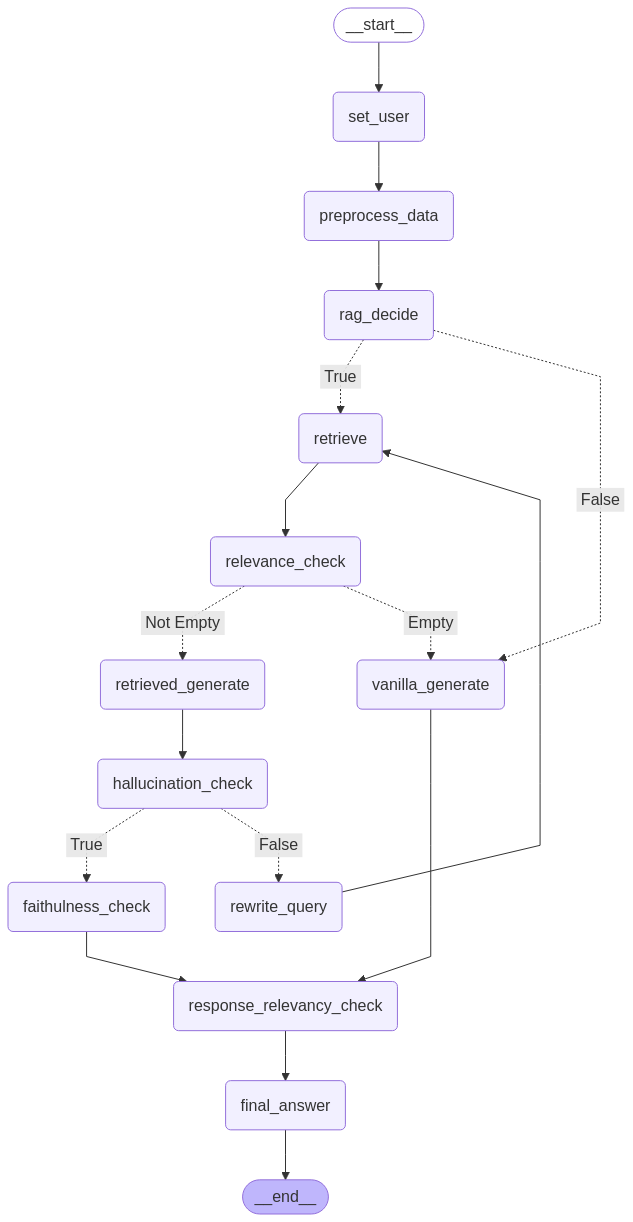

In [69]:
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableLambda

# (1): Conventional RAG
# (2): 재검색
# (3): 멀티 LLM
# (4): 쿼리 재작성


# langgraph.graph에서 StateGraph와 END를 가져옵니다.
workflow = StateGraph(GraphState)

# 노드를 추가합니다.
workflow.add_node("preprocess_data", preprocess_data)

workflow.add_node("rag_decide", rag_decide)

# RAG 여부 결정 

workflow.add_node('set_user', RunnableLambda(set_user_info))

workflow.set_entry_point("set_user")

workflow.add_edge(START, "set_user")

workflow.add_edge("set_user", "preprocess_data")

workflow.add_edge("preprocess_data", "rag_decide")

workflow.add_node("vanilla_generate", vanilla_generate)

workflow.add_node("retrieve", retrieve)

# 조건부 엣지를 추가
workflow.add_conditional_edges(
    "rag_decide",  # 관련성 체크 노드에서 나온 결과를 is_relevant 함수에 전달합니다.
    is_rag,
    {
        True: "retrieve",  # retrieve가 필요하면 수행 
        False: "vanilla_generate",  # 필요없으면 바로 생성  
    },
)

# RAG 수행 

workflow.add_node("relevance_check", relevance_check)


workflow.add_node("retrieved_generate", retrieved_generate)


# 각 노드들을 연결합니다.
workflow.add_edge("retrieve", "relevance_check")


# 조건부 엣지를 추가
workflow.add_conditional_edges(
    "relevance_check",  # context가 필터링 이후 
    is_context_empty,
    {
        'Not Empty': "retrieved_generate",  # contexts가 비어 있지 않다면 RAG로  
        'Empty': "vanilla_generate",  # 비었다면 일반 생성으로  
    },
)


# Hallucination 체크 

workflow.add_node("hallucination_check", hallucination_check)

workflow.add_edge("retrieved_generate", "hallucination_check")

workflow.add_node("rewrite_query", rewrite_query)

workflow.add_node("response_relevancy_check", response_relevancy_check)

workflow.add_node("faithulness_check", faithfulness_check)

workflow.add_edge("vanilla_generate", "response_relevancy_check")

# workflow.add_node("change_retriever", change_retriever) 

#workflow.add_node("search_on_web", search_on_web)


# 조건부 엣지를 추가
workflow.add_conditional_edges(
    "hallucination_check",  # 관련성 체크 노드에서 나온 결과를 is_relevant 함수에 전달합니다.
    is_grounded,
    {
        True: "faithulness_check",  # partially grounded 혹은 fully grounded면  
        False: "rewrite_query",  # NOT grounded 
    },
)

workflow.add_edge("rewrite_query", "retrieve")

workflow.add_edge("faithulness_check", "response_relevancy_check")

workflow.add_node('final_answer', final_answer)

workflow.add_edge("response_relevancy_check", "final_answer")

workflow.add_edge("final_answer", END)


# 기록을 위한 메모리 저장소를 설정합니다.
memory = MemorySaver()

checkpointer = InMemorySaver()

# 그래프를 컴파일합니다.
app = workflow.compile(checkpointer=checkpointer)

# 그래프 시각화
visualize_graph(app)

## 그래프 실행  

In [73]:
user_data = {"id": 123, 
            "name": "김철수", 
            "email": "chulsoo.kim@example.com", 
            "department": "executive", 
            "rank": "executive"}


# 실행 (예시)
inputs = {
    "question": "내년도 예산안에 대해서 알려줘"
}

config_checkpointer = {"configurable": {"thread_id": "1"}}

for output in app.stream(inputs, config_checkpointer):
    for key, value in output.items():
        print(f"Output from node '{key}': {value}")

Output from node 'set_user': {'user': {'id': 123, 'name': '김철수', 'email': 'chulsoo.kim@example.com', 'department': 'executive', 'rank': 'executive'}}
Output from node 'preprocess_data': {'question': '내년도 예산안에 대해서 알려줘'}
----- RAG Decision -----
content='[Retrieval]' additional_kwargs={} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []} id='run-b31e651b-73f8-4cb5-92dd-f4448933fdb1-0' usage_metadata={'input_tokens': 49, 'output_tokens': 4, 'total_tokens': 53, 'input_token_details': {'cache_read': 0}}
<class 'langchain_core.messages.ai.AIMessage'>
['[Retrieval]']
Output from node 'rag_decide': {'rag_decision': ['[Retrieval]']}
----- Retrieving Process -----
query of Retrieve: 내년도 예산안에 대해서 알려줘
vesctorestore path: faiss_index_marketing_A
Dept. marketing  
 retrieved contexts: [(Document(id='a4a2f1ed-e5da-4cd5-baf7-fa2d25860a21', metadata={'id': '4de6844e-c367-4f77-8849-4f88aa7b9a4d', 'department': 'marketing', 'ran

In [74]:
output

{'final_answer': {'messages': [('user', '내년도 예산안에 대해서 알려줘'),
   'assistant',
   '제공된 문서에 따르면, "[재무 - A] 내년도 예산안"은 2026년도 회사 전체 예산 계획을 담은 최종 검토 문서입니다.  이 문서에는 각 사업 부서(마케팅, 영업, R&D, 생산)의 예산 요청 내역, 예상 매출액 및 영업 이익, 투자 계획(신규 설비 투자, 연구 개발 투자 등), 거시 경제 전망 및 시장 상황 분석을 기반으로 한 재무 예측이 포함되어 있습니다.  특히 신규 사업 진출에 따른 추가 예산 확보 방안 및 비상 자금 운용 계획이 상세히 기술되어 있으며, 예산 집행 통제 및 평가 기준을 명확히 제시하여 효율적인 재정 관리를 목표로 합니다.  현재는 경영진의 최종 승인을 기다리고 있습니다.']}}

In [75]:
output['final_answer']

{'messages': [('user', '내년도 예산안에 대해서 알려줘'),
  'assistant',
  '제공된 문서에 따르면, "[재무 - A] 내년도 예산안"은 2026년도 회사 전체 예산 계획을 담은 최종 검토 문서입니다.  이 문서에는 각 사업 부서(마케팅, 영업, R&D, 생산)의 예산 요청 내역, 예상 매출액 및 영업 이익, 투자 계획(신규 설비 투자, 연구 개발 투자 등), 거시 경제 전망 및 시장 상황 분석을 기반으로 한 재무 예측이 포함되어 있습니다.  특히 신규 사업 진출에 따른 추가 예산 확보 방안 및 비상 자금 운용 계획이 상세히 기술되어 있으며, 예산 집행 통제 및 평가 기준을 명확히 제시하여 효율적인 재정 관리를 목표로 합니다.  현재는 경영진의 최종 승인을 기다리고 있습니다.']}

In [76]:
user_data = {"id": 123, 
            "name": "김철수", 
            "email": "chulsoo.kim@example.com", 
            "department": "marketing", 
            "rank": "staff"}


# 실행 (예시)
inputs = {
    "question": "내년도 예산안에 대해서 알려줘"
}

config_checkpointer = {"configurable": {"thread_id": "1"}}

for output in app.stream(inputs, config_checkpointer):
    for key, value in output.items():
        print(f"Output from node '{key}': {value}")

Output from node 'set_user': {'user': {'id': 123, 'name': '김철수', 'email': 'chulsoo.kim@example.com', 'department': 'marketing', 'rank': 'staff'}}
Output from node 'preprocess_data': {'question': '내년도 예산안에 대해서 알려줘'}
----- RAG Decision -----
content='[Retrieval]' additional_kwargs={} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []} id='run-990d4991-5e92-455b-8b76-0fa68508eda8-0' usage_metadata={'input_tokens': 49, 'output_tokens': 4, 'total_tokens': 53, 'input_token_details': {'cache_read': 0}}
<class 'langchain_core.messages.ai.AIMessage'>
['[Retrieval]']
Output from node 'rag_decide': {'rag_decision': ['[Retrieval]']}
----- Retrieving Process -----
query of Retrieve: 내년도 예산안에 대해서 알려줘
vesctorestore path: faiss_index_marketing_C
Dept. marketing  
 retrieved contexts: [(Document(id='7a841e05-e63f-4e3a-934d-b265053c4fb0', metadata={'id': '091e8dcb-0698-4f51-b9f5-8943f035ccd9', 'department': 'marketing', 'rank': 

## thread_id의 중요성  

thread_id가 개별 유저에 대해서 구분하는 아이디다.  

따라서 유저별로 이를 잘 구분해야 한다.  

그리고 유저별로 대화를 구분해야 하기 때문에 이를 추가적으로 구분해야 한다.  

In [77]:
user_data = {"id": 123, 
            "name": "김철수", 
            "email": "chulsoo.kim@example.com", 
            "department": "marketing", 
            "rank": "staff"}


# 실행 (예시)
inputs = {
    "question": "내년도 예산안에 대해서 알려줘"
}

config_checkpointer = {"configurable": {"thread_id": "2"}}

for output in app.stream(inputs, config_checkpointer):
    for key, value in output.items():
        print(f"Output from node '{key}': {value}")

Output from node 'set_user': {'user': {'id': 123, 'name': '김철수', 'email': 'chulsoo.kim@example.com', 'department': 'marketing', 'rank': 'staff'}}
Output from node 'preprocess_data': {'question': '내년도 예산안에 대해서 알려줘'}
----- RAG Decision -----
content='[Retrieval]' additional_kwargs={} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []} id='run-d80713de-2ffb-4c5f-8a6e-76b2c373cb8a-0' usage_metadata={'input_tokens': 49, 'output_tokens': 4, 'total_tokens': 53, 'input_token_details': {'cache_read': 0}}
<class 'langchain_core.messages.ai.AIMessage'>
['[Retrieval]']
Output from node 'rag_decide': {'rag_decision': ['[Retrieval]']}
----- Retrieving Process -----
query of Retrieve: 내년도 예산안에 대해서 알려줘
vesctorestore path: faiss_index_marketing_C
Dept. marketing  
 retrieved contexts: [(Document(id='7a841e05-e63f-4e3a-934d-b265053c4fb0', metadata={'id': '091e8dcb-0698-4f51-b9f5-8943f035ccd9', 'department': 'marketing', 'rank': 

In [78]:
output['final_answer']

{'messages': [('user', '내년도 예산안에 대해서 알려줘'),
  'assistant',
  '내년도 예산안에 대한 정보를 드리기 위해서는 어떤 부분에 대해 궁금하신지 구체적으로 알려주셔야 합니다.  회사, 부서, 혹은 특정 프로젝트에 대한 예산안 정보를 원하시는지,  예산안의 전체적인 규모, 주요 투자 분야, 예산 편성 기준 등에 대한 정보를 원하시는지 명확히 해주시면 더욱 정확한 답변을 드릴 수 있습니다.\n\n예를 들어, 다음과 같은 정보를 제공해주시면 도움이 됩니다:\n\n* **회사/부서:** 어떤 회사 또는 부서의 예산안에 관심이 있으십니까?\n* **예산 항목:**  어떤 항목의 예산에 대해 알고 싶으십니까? (예: 마케팅, 연구개발, 인건비 등)\n* **구체적인 질문:** 예산안과 관련하여 궁금한 점이 있다면 구체적으로 질문해주세요. (예: 예산 증감률, 예산 배정 기준, 예산 집행 계획 등)\n\n제공해주시는 정보에 따라,  관련 자료를 찾아보거나 담당 부서에 문의하여 정확한 정보를 제공해 드리겠습니다.']}